In [1]:
# ============================================================
# ZapKart Dark Store Intelligence
# Notebook 3: Exploratory Data Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Plot styling — makes every chart look professional
plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['figure.dpi']        = 150
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 14
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.labelsize']    = 11

# Color palette — consistent across all charts
COLORS = {
    'primary':   '#2563EB',
    'danger':    '#DC2626',
    'success':   '#16A34A',
    'warning':   '#D97706',
    'neutral':   '#6B7280',
    'light':     '#DBEAFE',
    'bangalore': '#2563EB',
    'mumbai':    '#16A34A',
    'delhi':     '#DC2626'
}

CITY_COLORS = ['#2563EB', '#16A34A', '#DC2626']

PROCESSED_PATH = "D:\Projects\End-to-end projects\9. ZapKart Dark-Store Intelligence\Data\Processed" + "\\"
CHARTS_PATH    = "D:\Projects\End-to-end projects\9. ZapKart Dark-Store Intelligence\Outputs\Charts" + "\\"
os.makedirs(CHARTS_PATH, exist_ok=True)

print("✅ Setup complete")

✅ Setup complete


In [2]:
# ============================================================
# Load all cleaned datasets
# ============================================================

dim_stores    = pd.read_csv(f"{PROCESSED_PATH}dim_stores_clean.csv",
                             parse_dates=['launch_date'])
dim_skus      = pd.read_csv(f"{PROCESSED_PATH}dim_skus_clean.csv")
dim_customers = pd.read_csv(f"{PROCESSED_PATH}dim_customers_clean.csv",
                             parse_dates=['signup_date'])
dim_pickers   = pd.read_csv(f"{PROCESSED_PATH}dim_pickers_clean.csv",
                             parse_dates=['join_date'])
fact_orders   = pd.read_csv(f"{PROCESSED_PATH}fact_orders_clean.csv",
                             parse_dates=['order_timestamp', 'order_date'])
fact_items    = pd.read_csv(f"{PROCESSED_PATH}fact_order_items_clean.csv",
                             parse_dates=['order_date'])
fact_pickers  = pd.read_csv(f"{PROCESSED_PATH}fact_picker_activity_clean.csv",
                             parse_dates=['order_date'])
fact_subs     = pd.read_csv(f"{PROCESSED_PATH}fact_substitutions_clean.csv",
                             parse_dates=['order_date'])

# Enrich orders with store info
orders = fact_orders.merge(
    dim_stores[['store_id', 'store_name', 'city', 'zone',
                'monthly_fixed_cost_inr', 'catchment_radius_km']],
    on='store_id', how='left')

print("=" * 55)
print("CLEANED DATA LOADED SUCCESSFULLY")
print("=" * 55)
print(f"  Orders:        {len(fact_orders):>10,}")
print(f"  Order Items:   {len(fact_items):>10,}")
print(f"  Picker Acts:   {len(fact_pickers):>10,}")
print(f"  Substitutions: {len(fact_subs):>10,}")
print(f"  Date Range:    {fact_orders['order_date'].min()} "
      f"to {fact_orders['order_date'].max()}")
print("=" * 55)

CLEANED DATA LOADED SUCCESSFULLY
  Orders:           453,036
  Order Items:    2,718,037
  Picker Acts:      412,015
  Substitutions:     54,396
  Date Range:    2023-01-01 00:00:00 to 2024-06-29 00:00:00


In [3]:
# ============================================================
# BUSINESS OVERVIEW — Top-level KPIs
# The numbers you quote in every interview
# ============================================================

total_orders      = len(orders)
total_revenue     = orders['net_order_value_inr'].sum()
total_profit      = orders['gross_profit_inr'].sum()
avg_order_value   = orders['net_order_value_inr'].mean()
avg_delivery_time = orders['total_delivery_mins'].mean()
sla_pct           = orders['sla_met'].mean() * 100
profitable_pct    = orders['is_profitable'].mean() * 100
total_customers   = orders['customer_id'].nunique()
cancellation_rate = (orders['order_status'] == 'Cancelled').mean() * 100
rto_rate          = (orders['order_status'] == 'RTO').mean() * 100

print("=" * 60)
print("  ZAPKART — BUSINESS OVERVIEW KPIs (18 Months)")
print("=" * 60)
print(f"  Total Orders:          {total_orders:>12,}")
print(f"  Total Revenue:         ₹{total_revenue:>12,.0f}")
print(f"  Total Gross Profit:    ₹{total_profit:>12,.0f}")
print(f"  Avg Order Value:       ₹{avg_order_value:>12,.2f}")
print(f"  Avg Delivery Time:     {avg_delivery_time:>11.1f} mins")
print(f"  SLA Achievement:       {sla_pct:>11.1f}%")
print(f"  Profitable Orders:     {profitable_pct:>11.1f}%")
print(f"  Unique Customers:      {total_customers:>12,}")
print(f"  Cancellation Rate:     {cancellation_rate:>11.1f}%")
print(f"  RTO Rate:              {rto_rate:>11.1f}%")
print("=" * 60)

  ZAPKART — BUSINESS OVERVIEW KPIs (18 Months)
  Total Orders:               453,036
  Total Revenue:         ₹ 150,110,781
  Total Gross Profit:    ₹ 137,874,001
  Avg Order Value:       ₹      331.34
  Avg Delivery Time:            15.9 mins
  SLA Achievement:               4.5%
  Profitable Orders:           100.0%
  Unique Customers:            49,980
  Cancellation Rate:             7.0%
  RTO Rate:                      2.0%


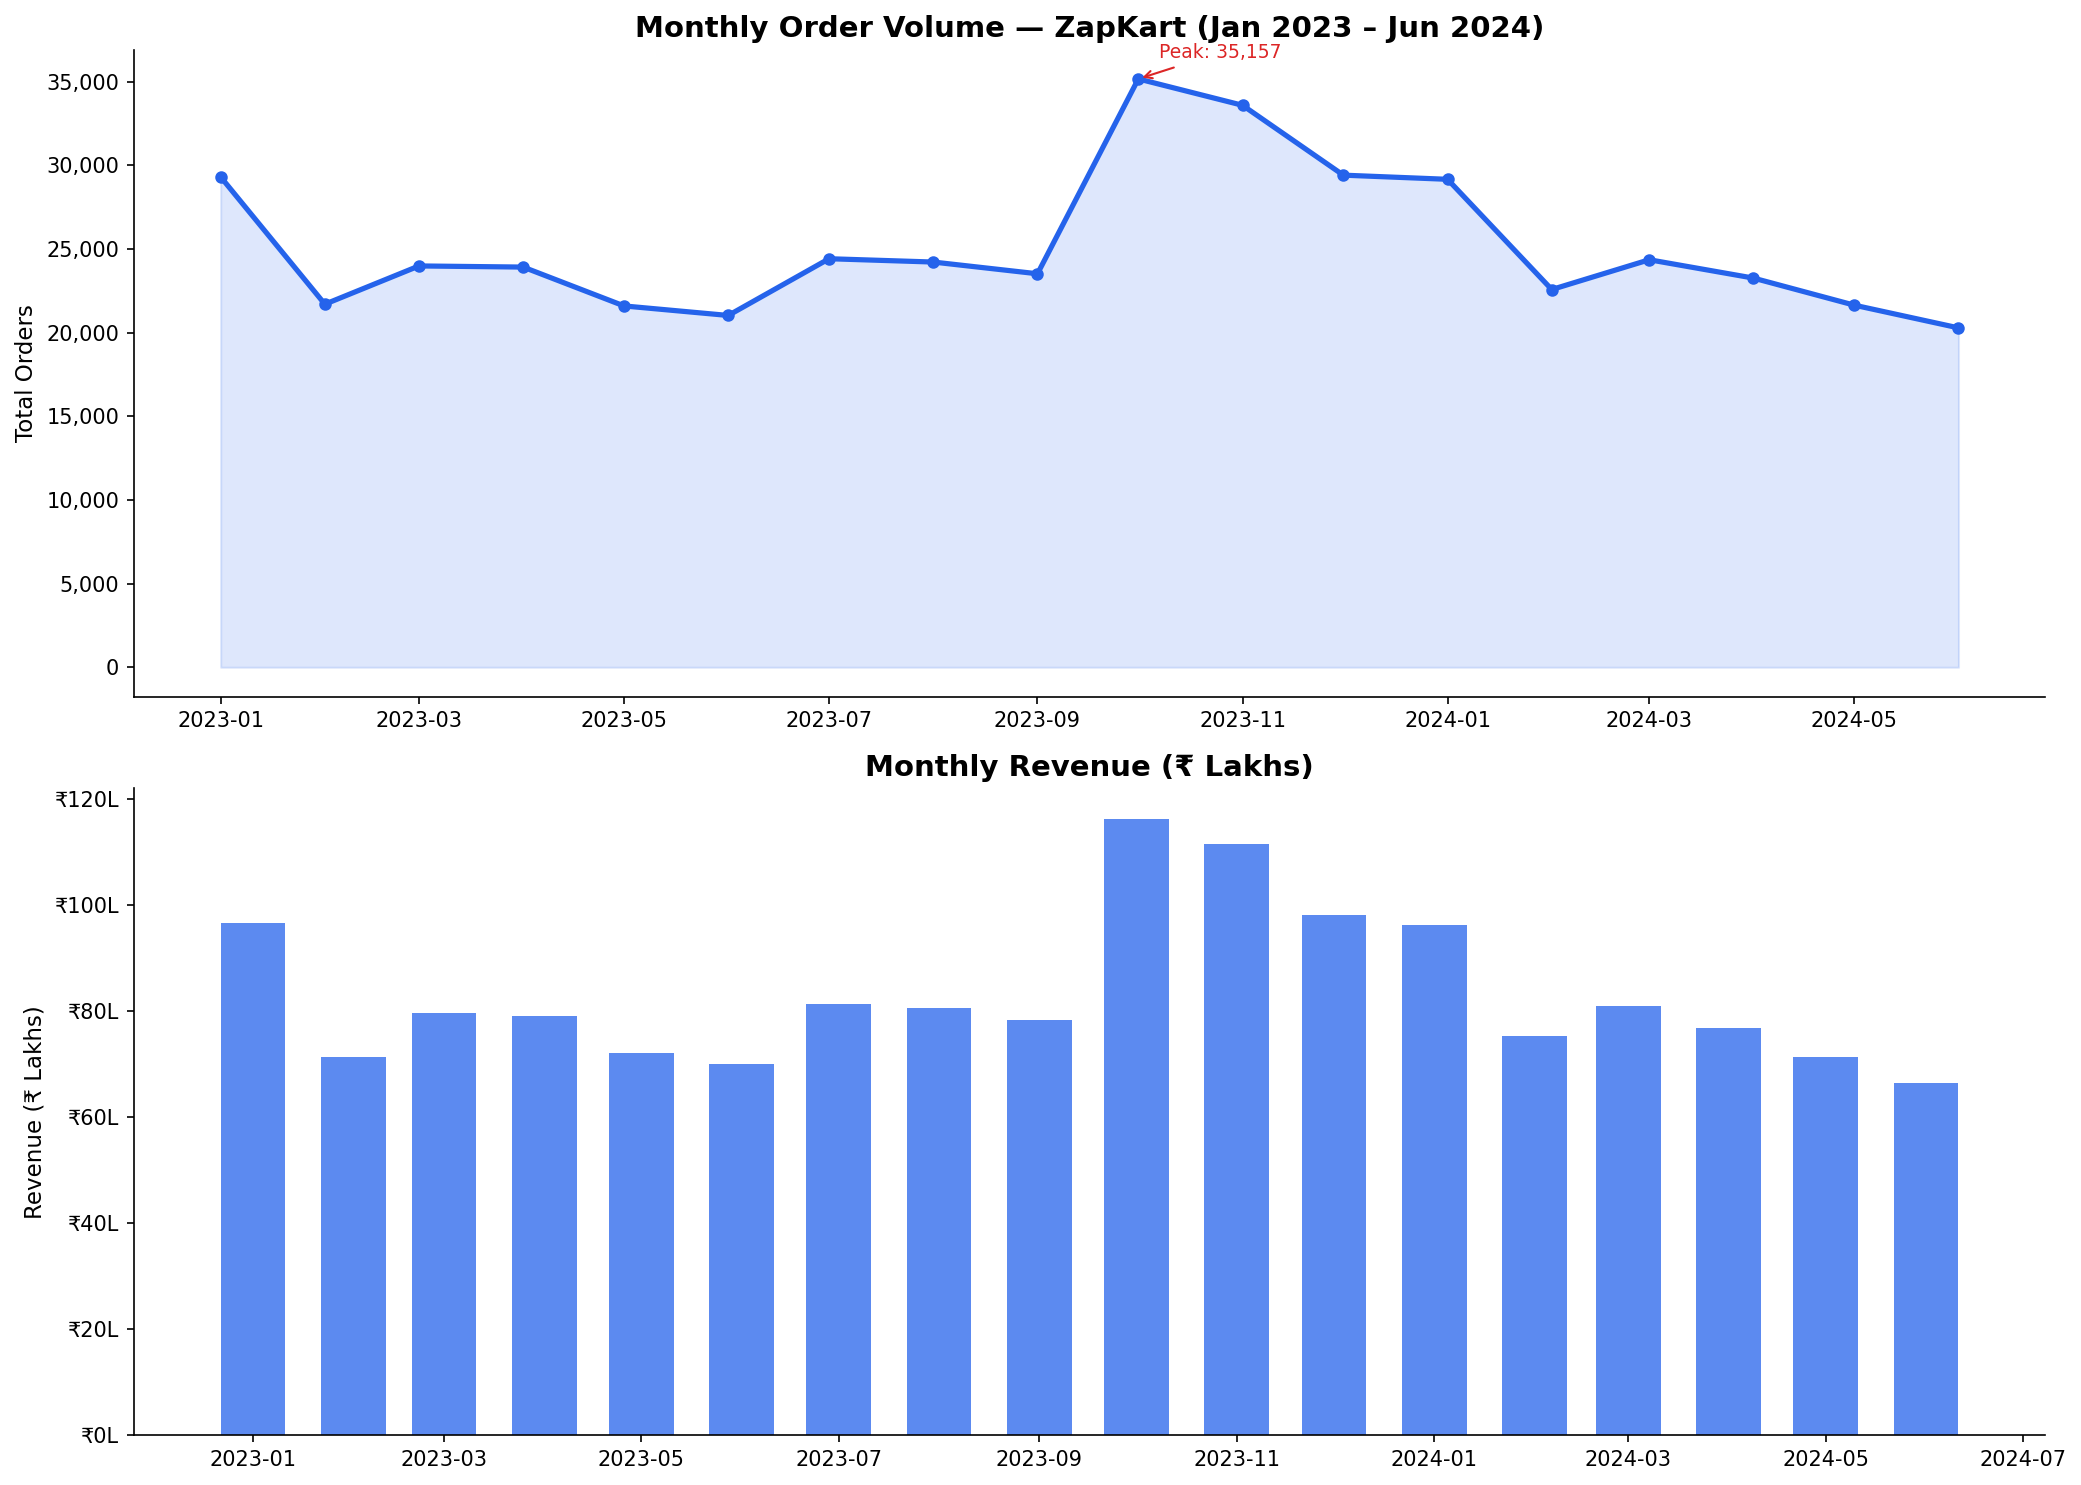

✅ Chart 1 saved


In [4]:
# ============================================================
# CHART 1: Monthly Order Volume Trend
# Business Question: Is ZapKart growing month over month?
# ============================================================

monthly = (orders.groupby(orders['order_date']
                           .dt.to_period('M'))
                  .agg(total_orders   = ('order_id',            'count'),
                       total_revenue  = ('net_order_value_inr', 'sum'),
                       avg_delivery   = ('total_delivery_mins', 'mean'),
                       sla_pct        = ('sla_met',             'mean'))
                  .reset_index())
monthly['order_date']  = monthly['order_date'].dt.to_timestamp()
monthly['sla_pct']    *= 100
monthly['revenue_lac'] = monthly['total_revenue'] / 100000

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: Order Volume
axes[0].fill_between(monthly['order_date'], monthly['total_orders'],
                      alpha=0.15, color=COLORS['primary'])
axes[0].plot(monthly['order_date'], monthly['total_orders'],
             color=COLORS['primary'], linewidth=2.5, marker='o',
             markersize=5)
axes[0].set_title('Monthly Order Volume — ZapKart (Jan 2023 – Jun 2024)')
axes[0].set_ylabel('Total Orders')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Annotate peak month
peak_idx = monthly['total_orders'].idxmax()
axes[0].annotate(
    f"Peak: {monthly.loc[peak_idx, 'total_orders']:,}",
    xy=(monthly.loc[peak_idx, 'order_date'],
        monthly.loc[peak_idx, 'total_orders']),
    xytext=(10, 10), textcoords='offset points',
    fontsize=9, color=COLORS['danger'],
    arrowprops=dict(arrowstyle='->', color=COLORS['danger']))

# Bottom: Revenue in Lakhs
axes[1].bar(monthly['order_date'], monthly['revenue_lac'],
            color=COLORS['primary'], alpha=0.75, width=20)
axes[1].set_title('Monthly Revenue (₹ Lakhs)')
axes[1].set_ylabel('Revenue (₹ Lakhs)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}L'))

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}01_monthly_order_trend.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 1 saved")

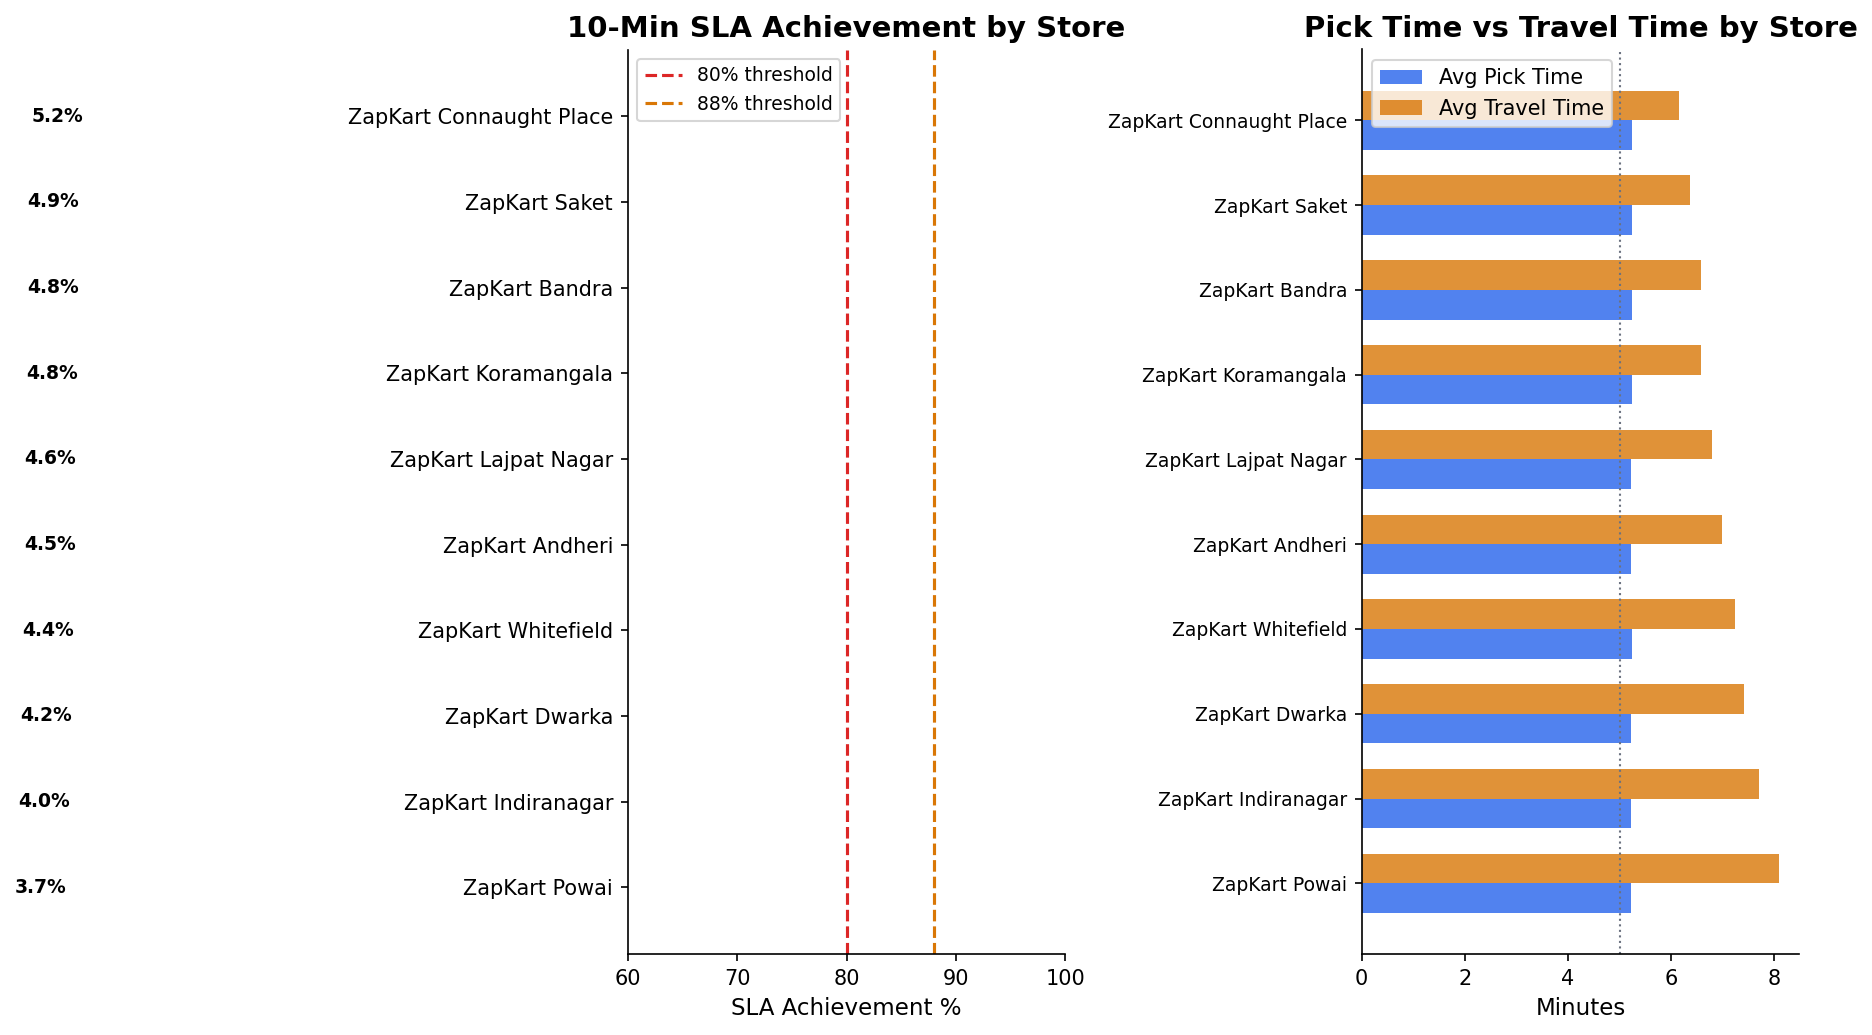


📊 SLA SUMMARY TABLE
             store_name      city  sla_met_pct  avg_delivery  avg_pick_time  avg_travel_time  total_orders
          ZapKart Powai    Mumbai         3.72         16.93           5.23             8.08         57866
    ZapKart Indiranagar Bengaluru         4.04         16.55           5.23             7.70         49637
         ZapKart Dwarka     Delhi         4.20         16.26           5.22             7.42         44260
     ZapKart Whitefield Bengaluru         4.38         16.09           5.24             7.23         32726
        ZapKart Andheri    Mumbai         4.55         15.83           5.22             6.98         44811
   ZapKart Lajpat Nagar     Delhi         4.60         15.63           5.23             6.78         39873
    ZapKart Koramangala Bengaluru         4.77         15.43           5.23             6.57         43089
         ZapKart Bandra    Mumbai         4.79         15.43           5.23             6.57         51695
          ZapKar

In [5]:
# ============================================================
# CHART 2: SLA Achievement by Store
# Business Question: Which stores are failing the
# 10-minute promise and by how much?
# ============================================================

store_sla = (orders.groupby(['store_id', 'store_name', 'city'])
                    .agg(total_orders    = ('order_id',            'count'),
                         sla_met_pct     = ('sla_met',             'mean'),
                         avg_delivery    = ('total_delivery_mins', 'mean'),
                         avg_pick_time   = ('pick_time_mins',      'mean'),
                         avg_travel_time = ('travel_time_mins',    'mean'))
                    .reset_index())
store_sla['sla_met_pct']  *= 100
store_sla['sla_fail_pct']  = 100 - store_sla['sla_met_pct']
store_sla = store_sla.sort_values('sla_met_pct')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: SLA % bar chart
bar_colors = [COLORS['danger'] if x < 80 else
              COLORS['warning'] if x < 88 else
              COLORS['success']
              for x in store_sla['sla_met_pct']]

bars = axes[0].barh(store_sla['store_name'],
                     store_sla['sla_met_pct'],
                     color=bar_colors, height=0.6)
axes[0].axvline(x=80, color=COLORS['danger'],
                linestyle='--', linewidth=1.5,
                label='80% threshold')
axes[0].axvline(x=88, color=COLORS['warning'],
                linestyle='--', linewidth=1.5,
                label='88% threshold')
axes[0].set_xlabel('SLA Achievement %')
axes[0].set_title('10-Min SLA Achievement by Store')
axes[0].set_xlim(60, 100)
axes[0].legend(fontsize=9)

for bar, val in zip(bars, store_sla['sla_met_pct']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9,
                 fontweight='bold')

# Right: Avg delivery time breakdown
width = 0.35
x     = np.arange(len(store_sla))
axes[1].barh(x - width/2, store_sla['avg_pick_time'],
             height=width, label='Avg Pick Time',
             color=COLORS['primary'], alpha=0.8)
axes[1].barh(x + width/2, store_sla['avg_travel_time'],
             height=width, label='Avg Travel Time',
             color=COLORS['warning'], alpha=0.8)
axes[1].axvline(x=5, color=COLORS['neutral'],
                linestyle=':', linewidth=1)
axes[1].set_yticks(x)
axes[1].set_yticklabels(store_sla['store_name'], fontsize=9)
axes[1].set_xlabel('Minutes')
axes[1].set_title('Pick Time vs Travel Time by Store')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}02_sla_by_store.png",
            bbox_inches='tight', dpi=150)
plt.show()

print("\n📊 SLA SUMMARY TABLE")
print(store_sla[['store_name', 'city', 'sla_met_pct',
                  'avg_delivery', 'avg_pick_time',
                  'avg_travel_time', 'total_orders']]
      .round(2).to_string(index=False))
print("✅ Chart 2 saved")

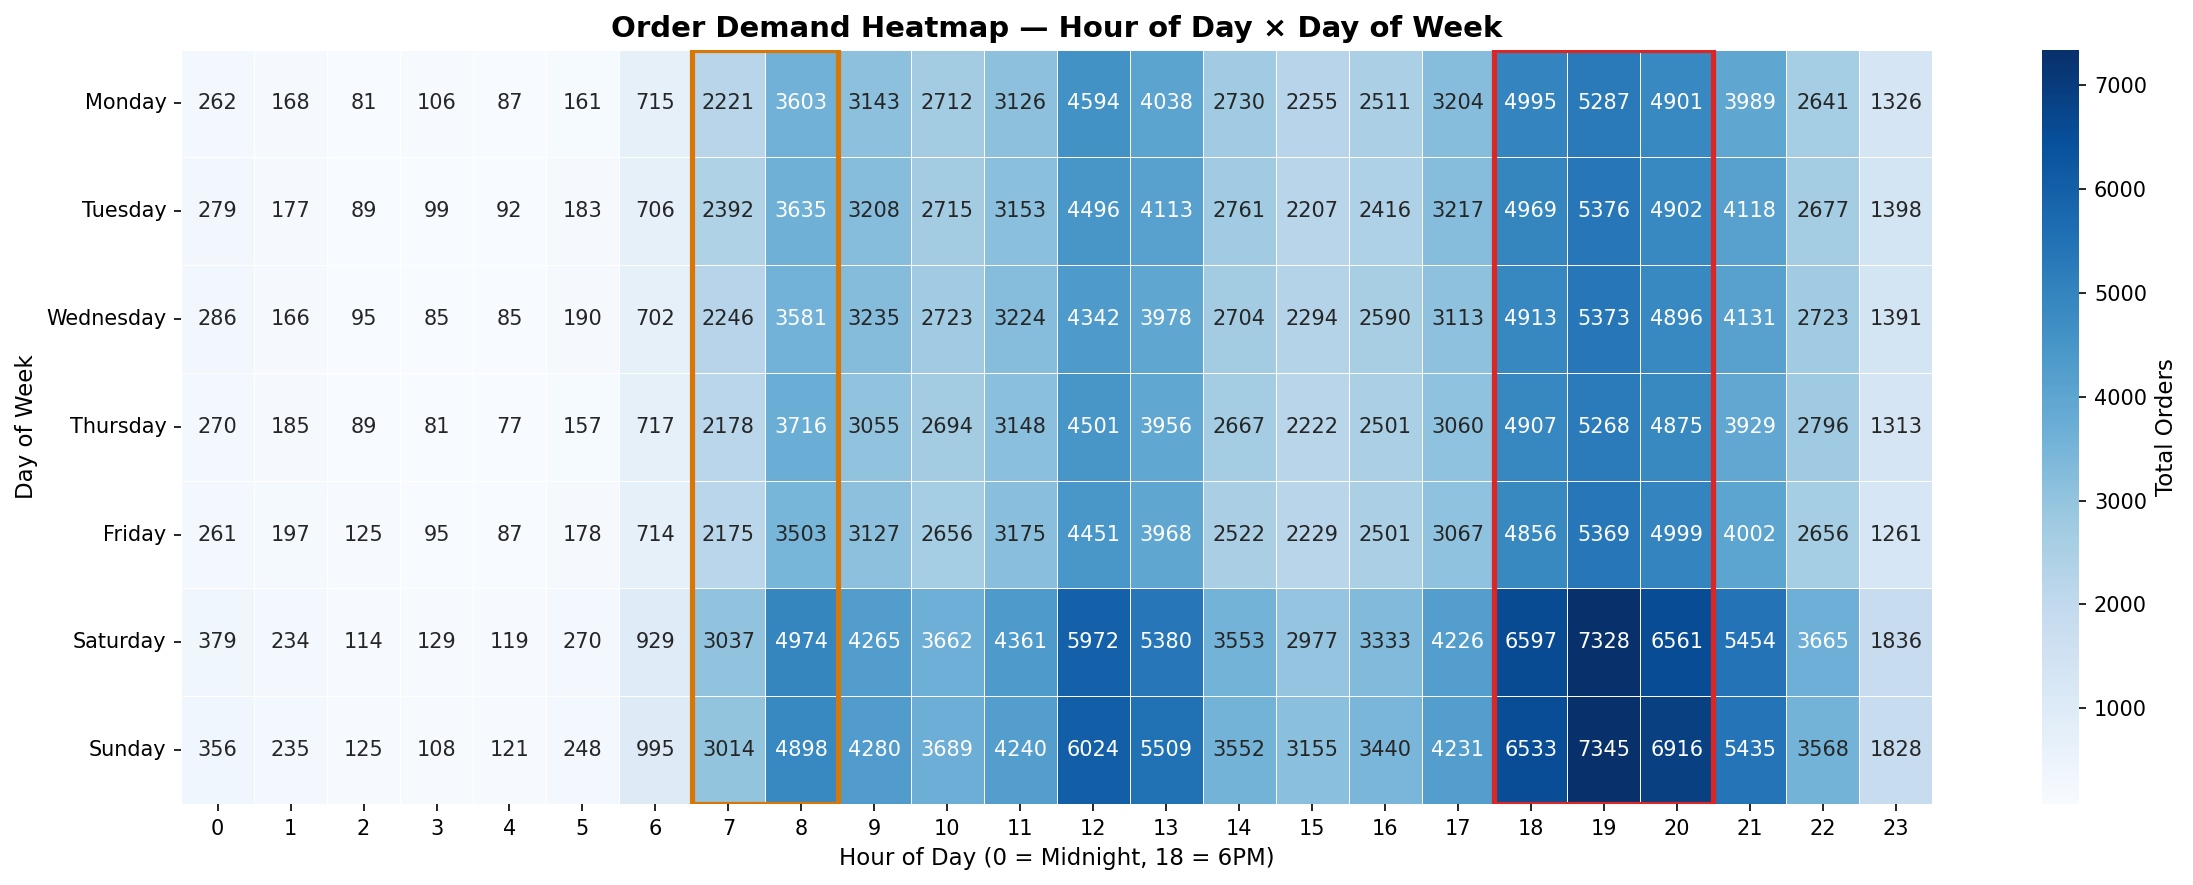

✅ Chart 3 saved


In [6]:
# ============================================================
# CHART 3: Hourly Demand Heatmap by Day of Week
# Business Question: When exactly is demand peaking?
# Used for: Picker shift planning
# ============================================================

orders['day_name'] = pd.to_datetime(
    orders['order_date']).dt.day_name()

day_hour = (orders.groupby(['day_name', 'order_hour'])
                   .agg(order_count=('order_id', 'count'))
                   .reset_index())

day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = day_hour.pivot(index='day_name',
                        columns='order_hour',
                        values='order_count').reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot,
            cmap='Blues',
            annot=True,
            fmt='.0f',
            linewidths=0.3,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Total Orders'})

ax.set_title('Order Demand Heatmap — Hour of Day × Day of Week',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day (0 = Midnight, 18 = 6PM)',
              fontsize=11)
ax.set_ylabel('Day of Week', fontsize=11)

# Mark peak zone
ax.add_patch(plt.Rectangle((18, 0), 3, 7,
             fill=False, edgecolor=COLORS['danger'],
             linewidth=2.5, label='Evening Peak Zone'))
ax.add_patch(plt.Rectangle((7, 0), 2, 7,
             fill=False, edgecolor=COLORS['warning'],
             linewidth=2.5, label='Morning Peak Zone'))

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}03_hourly_demand_heatmap.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 3 saved")

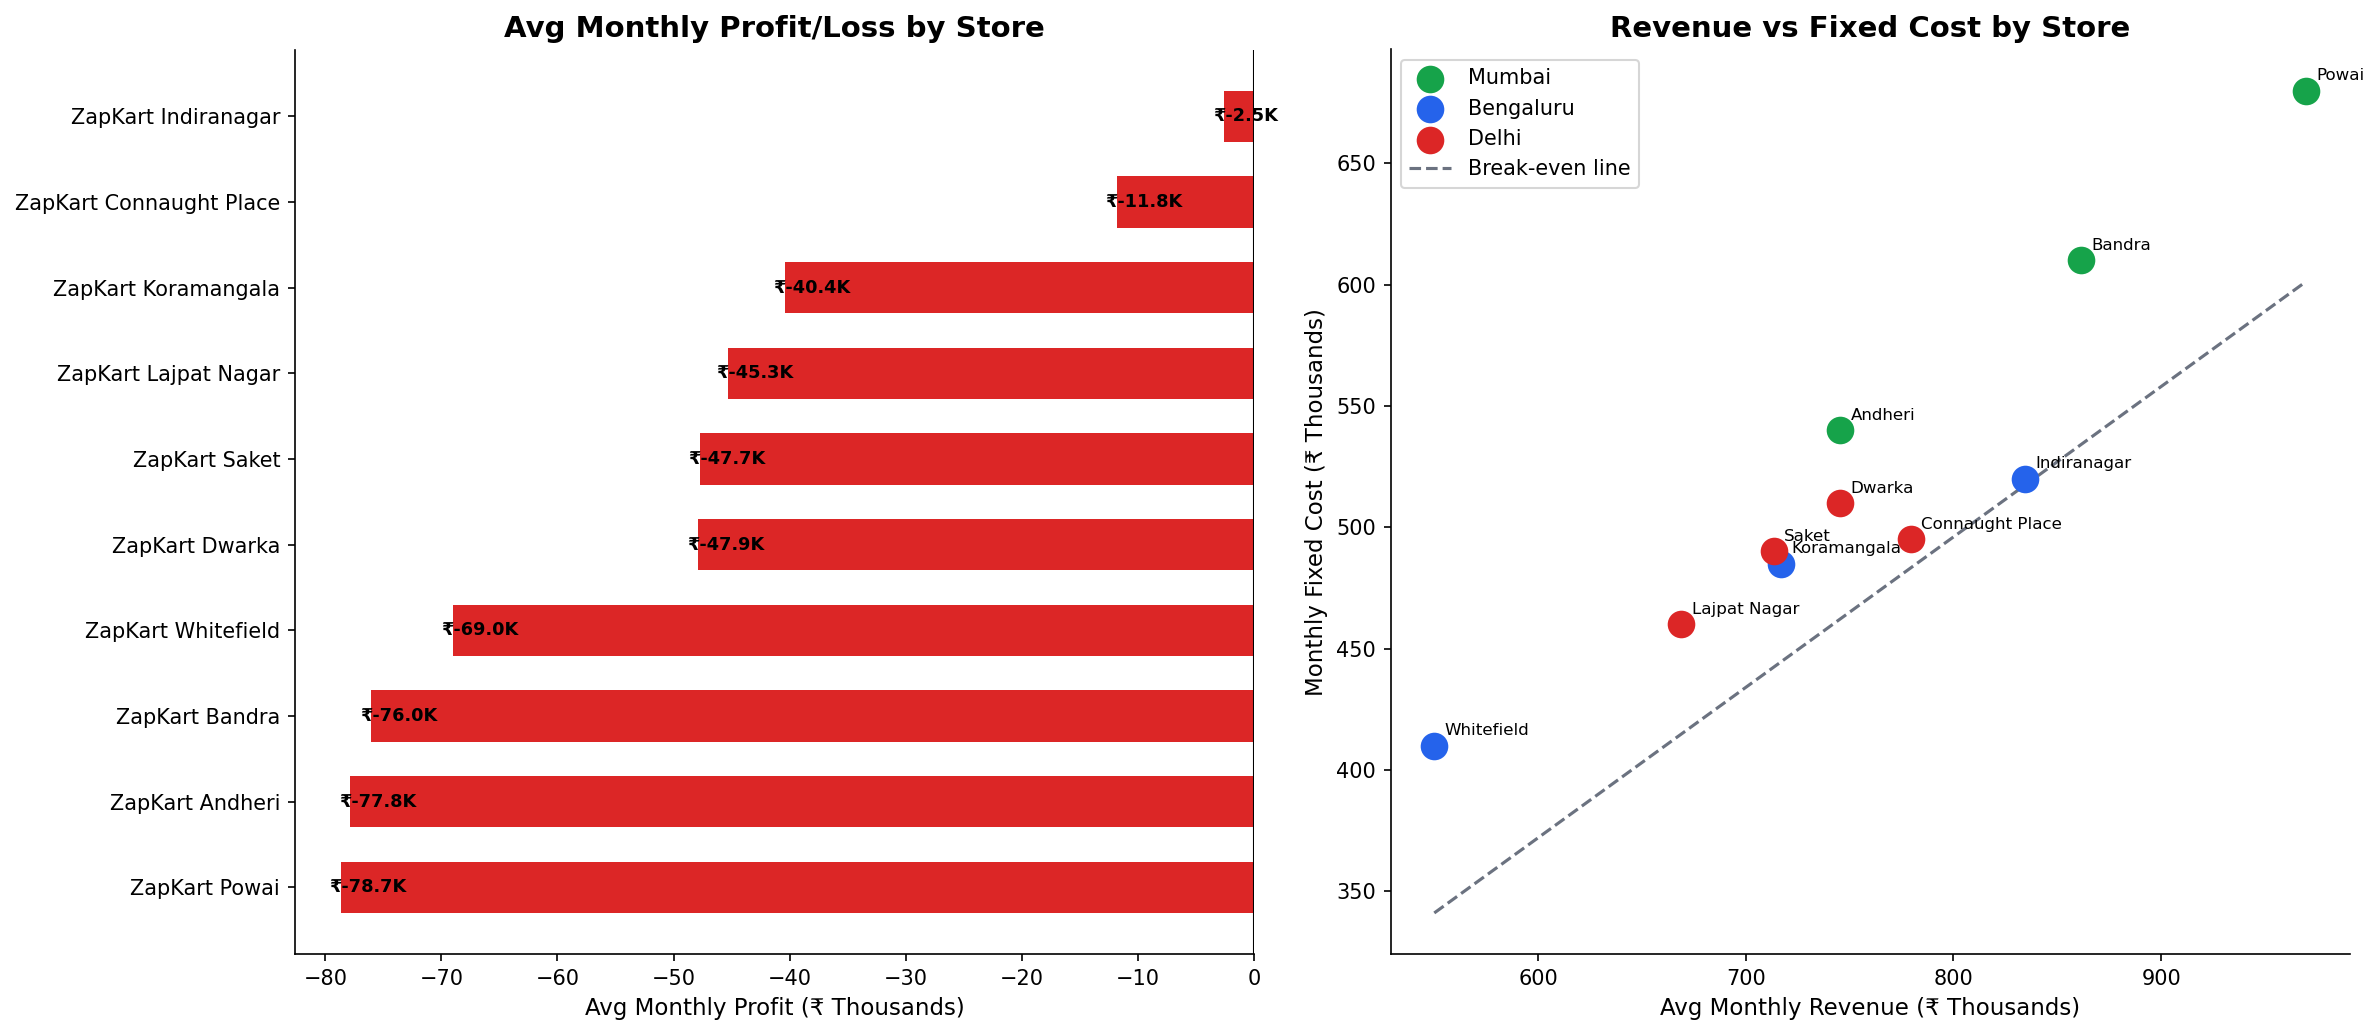


📊 STORE P&L SUMMARY
             store_name      city  avg_monthly_revenue  monthly_fixed_cost_inr  avg_monthly_profit  profit_margin_pct  is_profitable
          ZapKart Powai    Mumbai             969847.0                  680000            -78695.0               -8.0          False
        ZapKart Andheri    Mumbai             745414.0                  540000            -77843.0              -10.0          False
         ZapKart Bandra    Mumbai             861237.0                  610000            -76033.0               -9.0          False
     ZapKart Whitefield Bengaluru             549952.0                  410000            -69029.0              -13.0          False
         ZapKart Dwarka     Delhi             745373.0                  510000            -47869.0               -6.0          False
          ZapKart Saket     Delhi             713349.0                  490000            -47723.0               -7.0          False
   ZapKart Lajpat Nagar     Delhi             66

In [7]:
# ============================================================
# CHART 4: Store-Level P&L Overview
# Business Question: Which stores make money?
# Which ones are cash traps?
# ============================================================

# Revenue per store per month
store_monthly_revenue = (
    orders[orders['order_status'] == 'Delivered']
    .groupby(['store_id', 'store_name', 'city',
              'monthly_fixed_cost_inr',
              orders['order_date'].dt.to_period('M')
              .rename('month')])
    ['net_order_value_inr'].sum()
    .reset_index()
)

store_pnl = (store_monthly_revenue
             .groupby(['store_id', 'store_name',
                       'city', 'monthly_fixed_cost_inr'])
             .agg(avg_monthly_revenue = ('net_order_value_inr', 'mean'),
                  total_revenue       = ('net_order_value_inr', 'sum'),
                  months_active       = ('month',               'nunique'))
             .reset_index())

# Variable costs (delivery + ops) estimated at 38% of revenue
store_pnl['avg_variable_cost']   = store_pnl['avg_monthly_revenue'] * 0.38
store_pnl['avg_monthly_profit']  = (store_pnl['avg_monthly_revenue'] -
                                     store_pnl['avg_variable_cost'] -
                                     store_pnl['monthly_fixed_cost_inr'])
store_pnl['profit_margin_pct']   = (store_pnl['avg_monthly_profit'] /
                                     store_pnl['avg_monthly_revenue'] * 100)
store_pnl['is_profitable']       = store_pnl['avg_monthly_profit'] > 0
store_pnl = store_pnl.sort_values('avg_monthly_profit', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Monthly profit bar
profit_colors = [COLORS['success'] if x > 0 else COLORS['danger']
                 for x in store_pnl['avg_monthly_profit']]
bars = axes[0].barh(store_pnl['store_name'],
                     store_pnl['avg_monthly_profit'] / 1000,
                     color=profit_colors, height=0.6)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_xlabel('Avg Monthly Profit (₹ Thousands)')
axes[0].set_title('Avg Monthly Profit/Loss by Store')

for bar, val in zip(bars, store_pnl['avg_monthly_profit']):
    label_x = val/1000 + (1 if val >= 0 else -1)
    axes[0].text(label_x,
                 bar.get_y() + bar.get_height()/2,
                 f'₹{val/1000:.1f}K',
                 va='center', fontsize=8.5,
                 color='black', fontweight='bold')

# Right: Revenue vs Fixed Cost scatter
city_color_map = {'Bengaluru': COLORS['bangalore'],
                  'Mumbai':    COLORS['mumbai'],
                  'Delhi':     COLORS['delhi']}

for city in store_pnl['city'].unique():
    subset = store_pnl[store_pnl['city'] == city]
    axes[1].scatter(subset['avg_monthly_revenue'] / 1000,
                    subset['monthly_fixed_cost_inr'] / 1000,
                    label=city, s=150,
                    color=city_color_map.get(city, 'gray'),
                    zorder=5)
    for _, row in subset.iterrows():
        axes[1].annotate(
            row['store_name'].replace('ZapKart ', ''),
            (row['avg_monthly_revenue']/1000,
             row['monthly_fixed_cost_inr']/1000),
            textcoords='offset points',
            xytext=(5, 5), fontsize=8)

# Break-even line (fixed cost = 62% of revenue assuming 38% variable)
x_range = np.linspace(
    store_pnl['avg_monthly_revenue'].min()/1000,
    store_pnl['avg_monthly_revenue'].max()/1000, 100)
axes[1].plot(x_range, x_range * 0.62, '--',
             color=COLORS['neutral'], linewidth=1.5,
             label='Break-even line')

axes[1].set_xlabel('Avg Monthly Revenue (₹ Thousands)')
axes[1].set_ylabel('Monthly Fixed Cost (₹ Thousands)')
axes[1].set_title('Revenue vs Fixed Cost by Store')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}04_store_pnl_overview.png",
            bbox_inches='tight', dpi=150)
plt.show()

print("\n📊 STORE P&L SUMMARY")
print(store_pnl[['store_name', 'city',
                  'avg_monthly_revenue',
                  'monthly_fixed_cost_inr',
                  'avg_monthly_profit',
                  'profit_margin_pct',
                  'is_profitable']]
      .round(0).to_string(index=False))
print("✅ Chart 4 saved")

Columns after merge: ['activity_id', 'order_id', 'picker_id', 'store_id', 'pick_start_time', 'pick_end_time', 'pick_duration_mins', 'items_picked', 'pick_rate_per_min', 'errors_made', 'order_date', 'shift', 'productivity_band', 'skill_level', 'shift_picker', 'store_name', 'city']
Rows: 412015


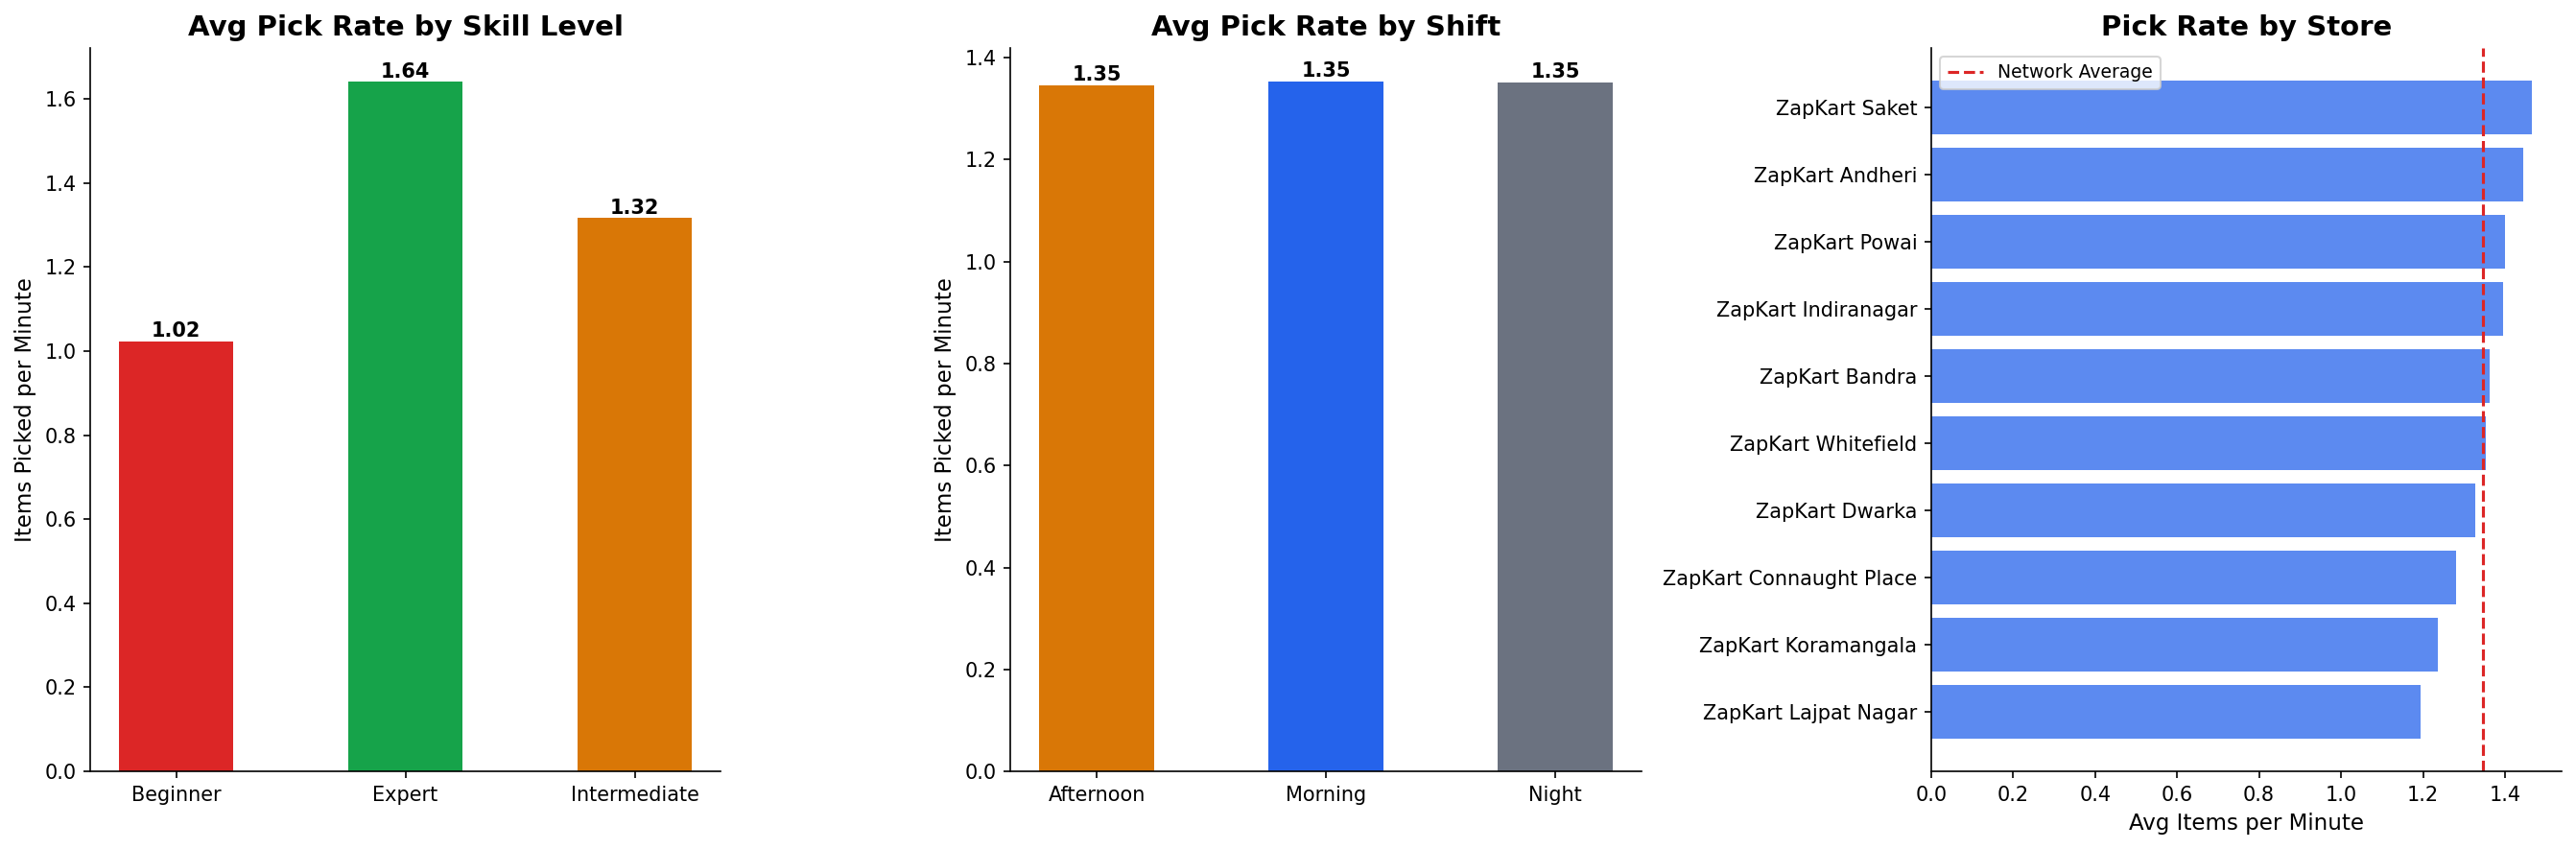


📊 SKILL LEVEL PRODUCTIVITY
 skill_level  avg_pick_rate  avg_pick_dur  avg_items_picked  total_activities
    Beginner          1.024         5.233             5.994             77929
      Expert          1.640         5.234             6.004            113112
Intermediate          1.316         5.225             6.002            220974

📊 SHIFT PRODUCTIVITY & ERROR RATE
    shift  avg_pick_rate  error_rate
Afternoon          1.345       0.180
  Morning          1.352       0.180
    Night          1.351       0.178
✅ Chart 5 saved


In [8]:
# ============================================================
# CHART 5: Picker Productivity Analysis
# ============================================================

# Step 1: Merge fact_pickers with dim_pickers cleanly
picker_stats = fact_pickers.merge(
    dim_pickers[['picker_id', 'skill_level', 'store_id', 'shift']],
    on='picker_id',
    how='left',
    suffixes=('', '_picker')   # avoid duplicate column conflict
)

# Step 2: Rename store_id from dim_pickers if duplicated
if 'store_id_picker' in picker_stats.columns:
    picker_stats.drop(columns=['store_id_picker'], inplace=True)

# Step 3: Now merge with dim_stores safely
picker_stats = picker_stats.merge(
    dim_stores[['store_id', 'store_name', 'city']],
    on='store_id',
    how='left'
)

# Quick check — print columns to confirm no duplicates
print("Columns after merge:", picker_stats.columns.tolist())
print("Rows:", len(picker_stats))

# Productivity by skill level
skill_prod = (picker_stats.groupby('skill_level')
                           .agg(avg_pick_rate    = ('pick_rate_per_min', 'mean'),
                                avg_pick_dur     = ('pick_duration_mins','mean'),
                                avg_items_picked = ('items_picked',      'mean'),
                                total_activities = ('activity_id',       'count'))
                           .reset_index())

# Productivity by shift
shift_prod = (picker_stats.groupby('shift')
                           .agg(avg_pick_rate = ('pick_rate_per_min', 'mean'),
                                error_rate    = ('errors_made',       'mean'))
                           .reset_index())

# Productivity by store
store_prod = (picker_stats.groupby('store_name')
                           .agg(avg_pick_rate = ('pick_rate_per_min', 'mean'))
                           .reset_index()
                           .sort_values('avg_pick_rate'))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: Pick rate by skill level
skill_colors = {'Expert':       COLORS['success'],
                'Intermediate': COLORS['warning'],
                'Beginner':     COLORS['danger']}
bars = axes[0].bar(skill_prod['skill_level'],
                    skill_prod['avg_pick_rate'],
                    color=[skill_colors.get(s, COLORS['primary'])
                           for s in skill_prod['skill_level']],
                    width=0.5)
axes[0].set_title('Avg Pick Rate by Skill Level')
axes[0].set_ylabel('Items Picked per Minute')
for bar, val in zip(bars, skill_prod['avg_pick_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center',
                 fontsize=10, fontweight='bold')

# Middle: Pick rate by shift
shift_colors_list = [COLORS['warning'], COLORS['primary'],
                     COLORS['neutral']]
bars2 = axes[1].bar(shift_prod['shift'],
                     shift_prod['avg_pick_rate'],
                     color=shift_colors_list[:len(shift_prod)],
                     width=0.5)
axes[1].set_title('Avg Pick Rate by Shift')
axes[1].set_ylabel('Items Picked per Minute')
for bar, val in zip(bars2, shift_prod['avg_pick_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center',
                 fontsize=10, fontweight='bold')

# Right: Pick rate by store
axes[2].barh(store_prod['store_name'],
              store_prod['avg_pick_rate'],
              color=COLORS['primary'], alpha=0.75)
axes[2].axvline(x=store_prod['avg_pick_rate'].mean(),
                color=COLORS['danger'], linestyle='--',
                linewidth=1.5, label='Network Average')
axes[2].set_xlabel('Avg Items per Minute')
axes[2].set_title('Pick Rate by Store')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}05_picker_productivity.png",
            bbox_inches='tight', dpi=150)
plt.show()

print("\n📊 SKILL LEVEL PRODUCTIVITY")
print(skill_prod.round(3).to_string(index=False))
print("\n📊 SHIFT PRODUCTIVITY & ERROR RATE")
print(shift_prod.round(3).to_string(index=False))
print("✅ Chart 5 saved")

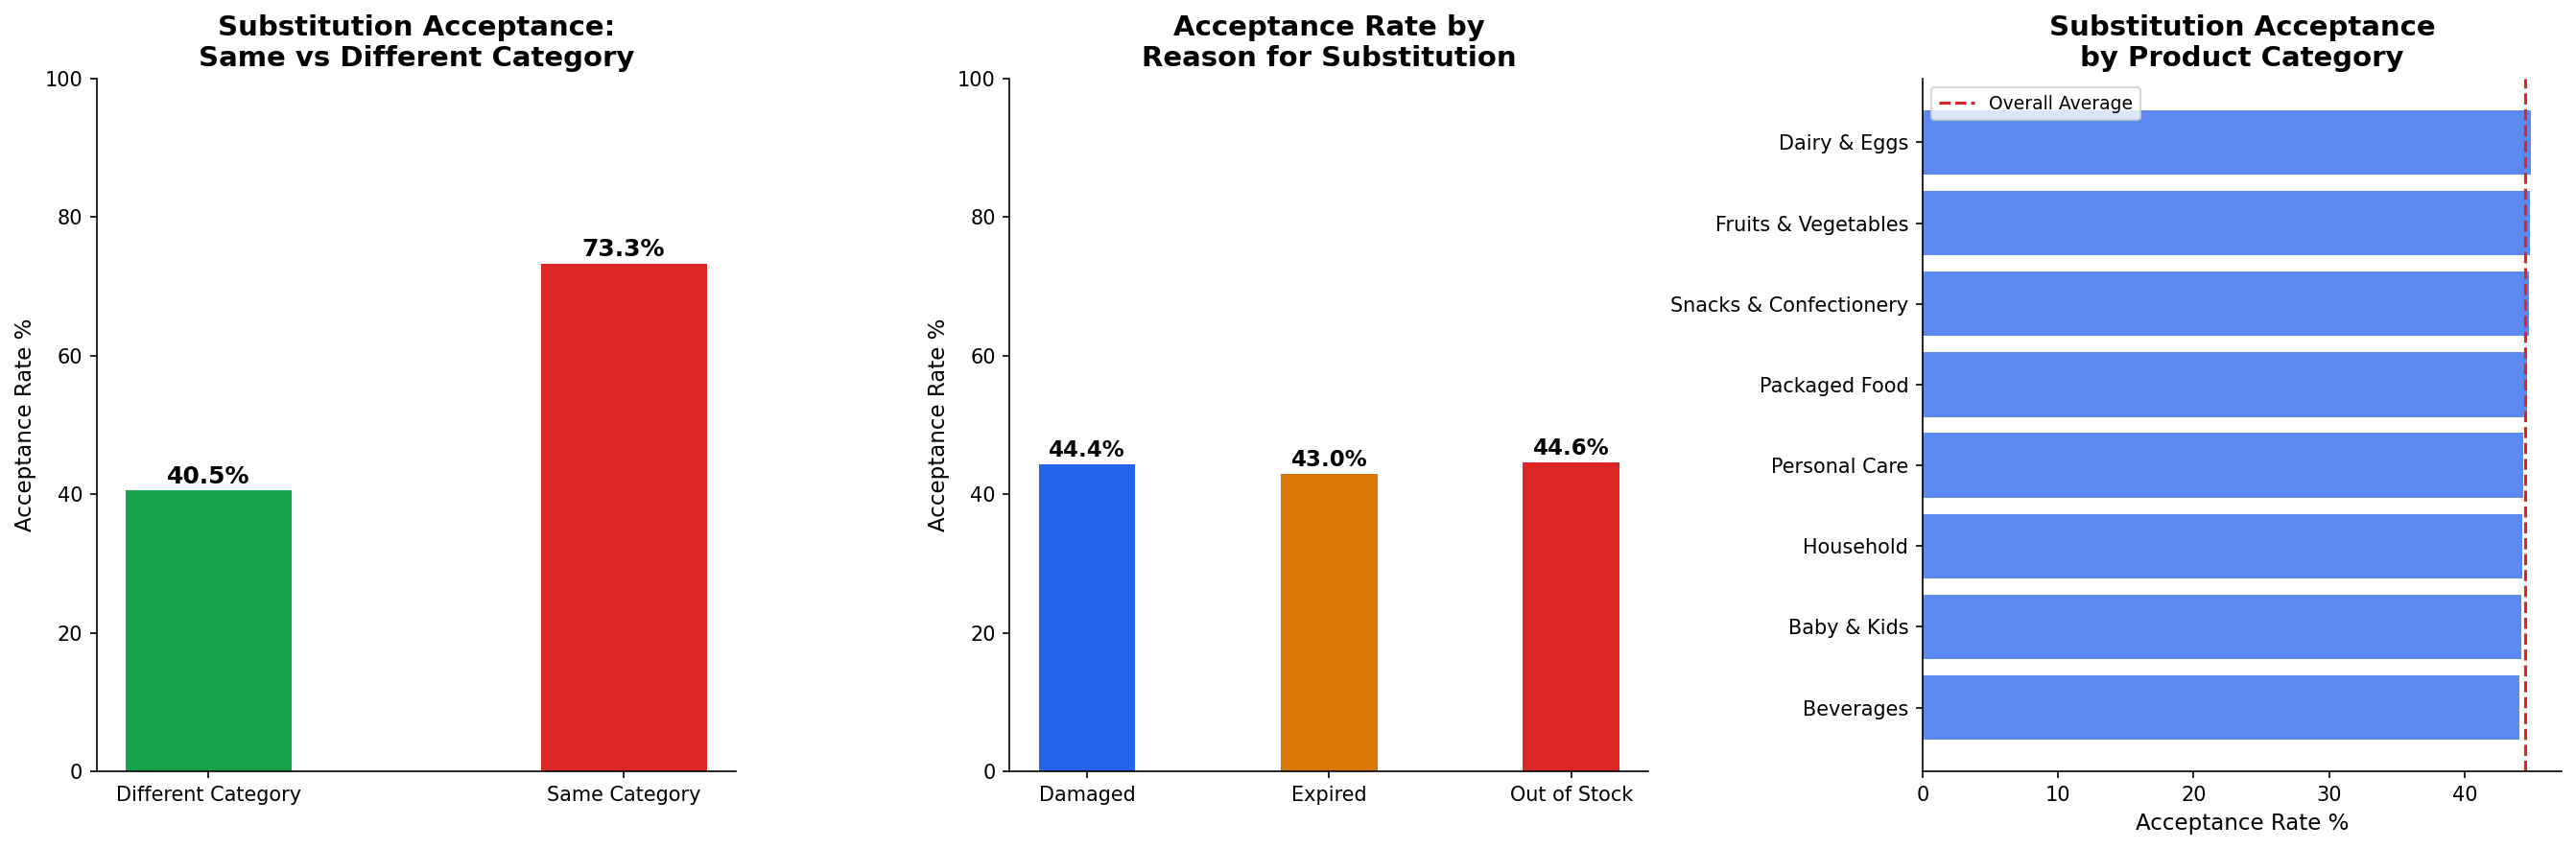


📊 SUBSTITUTION ACCEPTANCE BY CATEGORY MATCH
     same_category  acceptance_rate  total_subs
Different Category        40.535401       47852
     Same Category        73.319071        6544

📊 BY REASON
reason_for_sub  acceptance_rate  total_subs
       Damaged            44.39        7509
       Expired            42.99        4227
  Out of Stock            44.64       42660
✅ Chart 6 saved


In [9]:
# ============================================================
# CHART 6: Substitution Acceptance Analysis
# Business Question: Which substitutions work and
# which ones cause customer frustration?
# ============================================================

subs = fact_subs.merge(
    dim_skus[['sku_id', 'sku_name', 'category',
              'unit_price_inr']].rename(
        columns={'sku_id':          'original_sku_id',
                 'sku_name':        'original_sku_name',
                 'unit_price_inr':  'original_price'}),
    on='original_sku_id', how='left')

# Acceptance by same vs different category
cat_accept = (subs.groupby('same_category')
                   .agg(acceptance_rate = ('customer_accepted', 'mean'),
                        total_subs      = ('substitution_id',   'count'))
                   .reset_index())
cat_accept['acceptance_rate'] *= 100
cat_accept['same_category']    = cat_accept['same_category'].map(
    {True: 'Same Category', False: 'Different Category'})

# Acceptance by reason
reason_accept = (subs.groupby('reason_for_sub')
                      .agg(acceptance_rate = ('customer_accepted', 'mean'),
                           total_subs      = ('substitution_id',   'count'))
                      .reset_index())
reason_accept['acceptance_rate'] *= 100

# Acceptance rate by original category
orig_cat_accept = (subs.groupby('original_category')
                        .agg(acceptance_rate = ('customer_accepted', 'mean'),
                             total_subs      = ('substitution_id',   'count'))
                        .reset_index()
                        .sort_values('acceptance_rate'))
orig_cat_accept['acceptance_rate'] *= 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: Same vs different category
colors_cat = [COLORS['success'], COLORS['danger']]
bars = axes[0].bar(cat_accept['same_category'],
                    cat_accept['acceptance_rate'],
                    color=colors_cat, width=0.4)
axes[0].set_title('Substitution Acceptance:\nSame vs Different Category')
axes[0].set_ylabel('Acceptance Rate %')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, cat_accept['acceptance_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}%', ha='center',
                 fontsize=12, fontweight='bold')

# Middle: By reason for substitution
reason_colors = [COLORS['primary'], COLORS['warning'], COLORS['danger']]
bars2 = axes[1].bar(reason_accept['reason_for_sub'],
                     reason_accept['acceptance_rate'],
                     color=reason_colors, width=0.4)
axes[1].set_title('Acceptance Rate by\nReason for Substitution')
axes[1].set_ylabel('Acceptance Rate %')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, reason_accept['acceptance_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}%', ha='center',
                 fontsize=11, fontweight='bold')

# Right: By original category
axes[2].barh(orig_cat_accept['original_category'],
              orig_cat_accept['acceptance_rate'],
              color=COLORS['primary'], alpha=0.75)
axes[2].axvline(x=subs['customer_accepted'].mean()*100,
                color=COLORS['danger'], linestyle='--',
                linewidth=1.5, label='Overall Average')
axes[2].set_xlabel('Acceptance Rate %')
axes[2].set_title('Substitution Acceptance\nby Product Category')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}06_substitution_analysis.png",
            bbox_inches='tight', dpi=150)
plt.show()

print("\n📊 SUBSTITUTION ACCEPTANCE BY CATEGORY MATCH")
print(cat_accept.to_string(index=False))
print("\n📊 BY REASON")
print(reason_accept.round(2).to_string(index=False))
print("✅ Chart 6 saved")

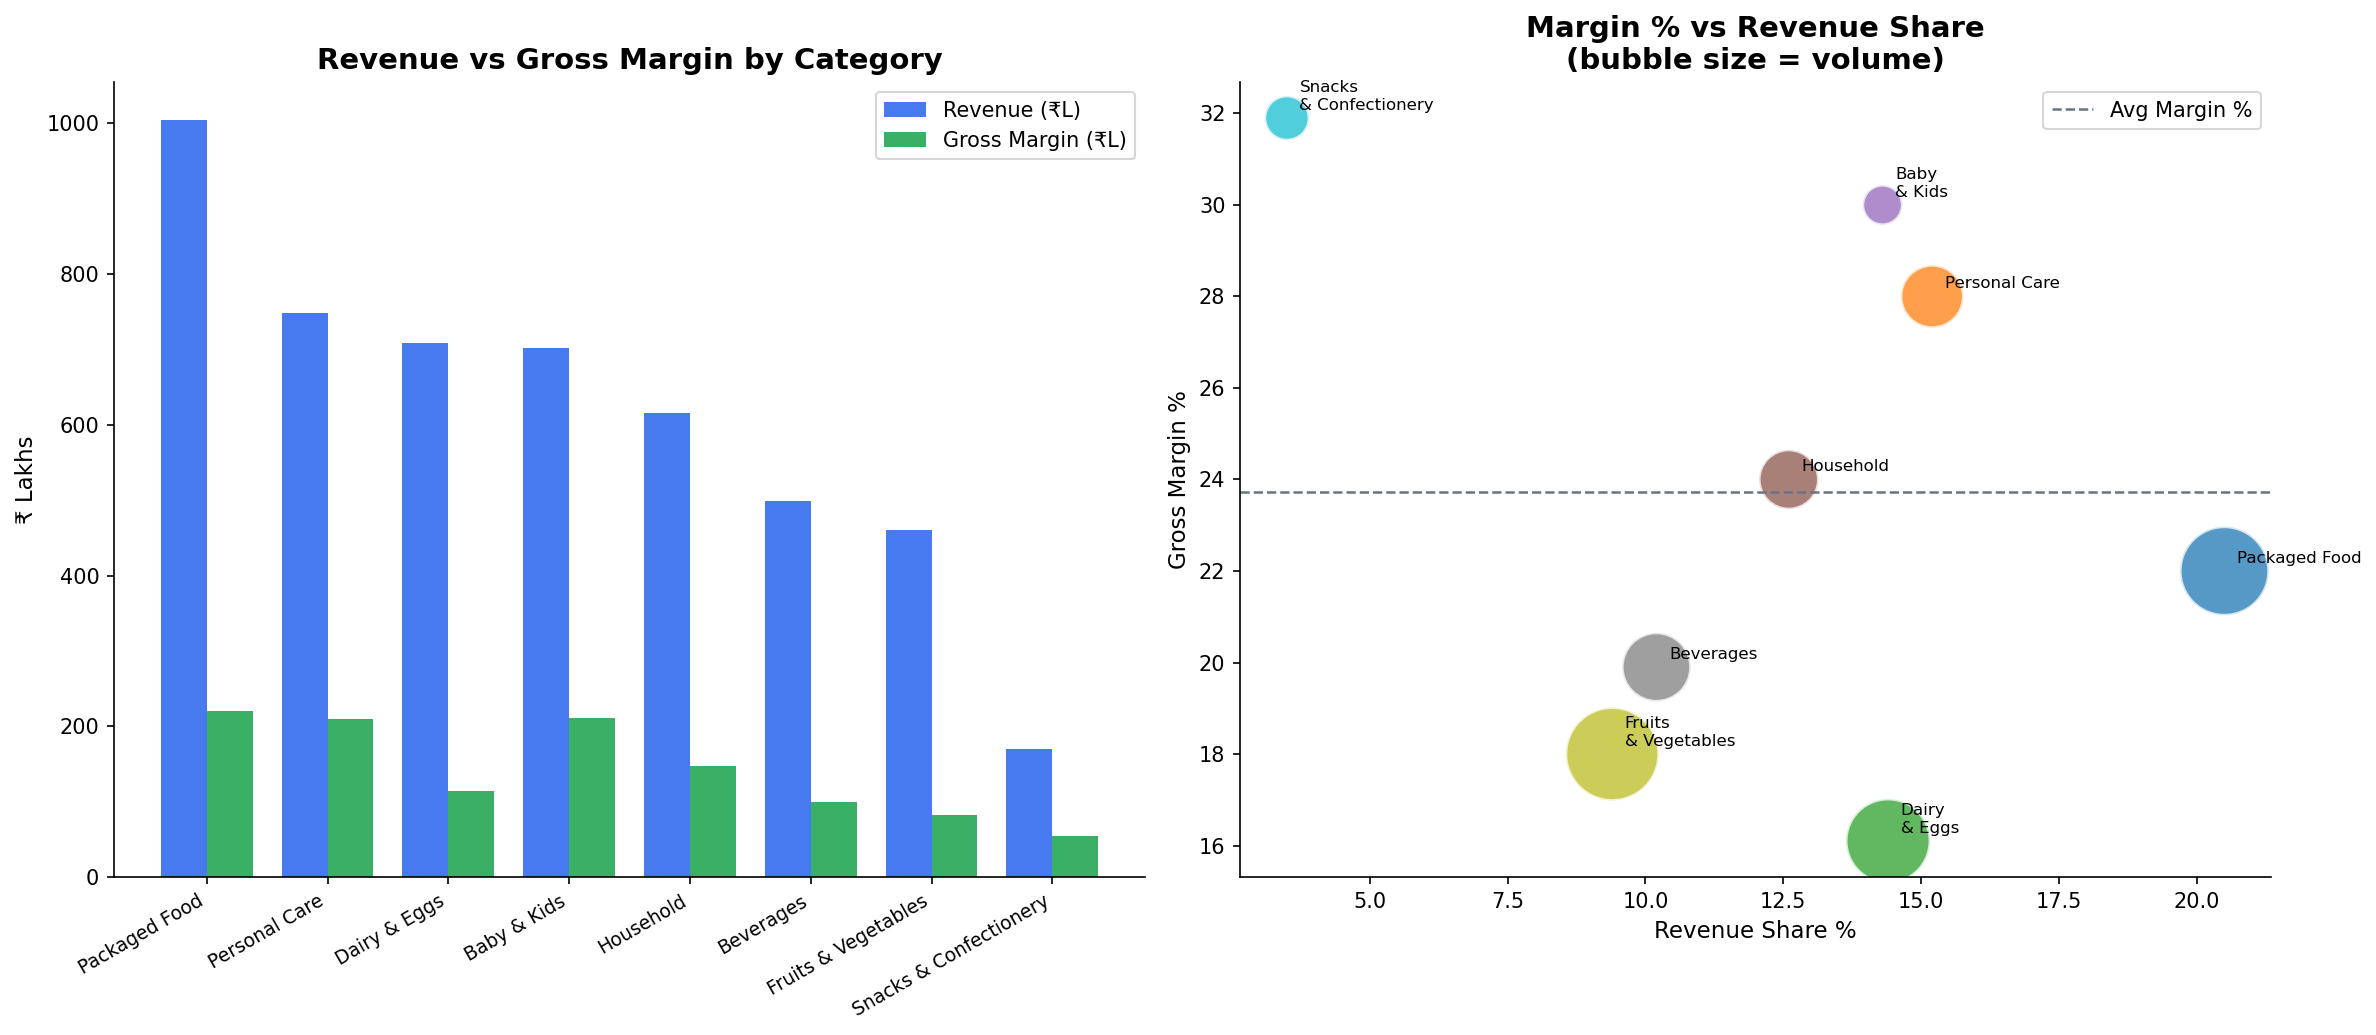


📊 CATEGORY PERFORMANCE SUMMARY
              category  revenue_lac  margin_pct  revenue_share  order_count
         Packaged Food       1004.5        22.0           20.5       302623
         Personal Care        747.6        28.0           15.2       198570
          Dairy & Eggs        708.3        16.1           14.4       286581
           Baby & Kids        702.2        30.0           14.3        95615
             Household        616.0        24.0           12.6       183698
             Beverages        498.6        19.9           10.2       224686
   Fruits & Vegetables        460.1        18.0            9.4       316758
Snacks & Confectionery        170.1        31.9            3.5       116060
✅ Chart 7 saved


In [10]:
# ============================================================
# CHART 7: Category Revenue & Margin Analysis
# Business Question: Which categories drive revenue
# vs which drive profit?
# ============================================================

cat_perf = (fact_items
            .groupby('category')
            .agg(total_revenue = ('item_total_inr',  'sum'),
                 total_margin  = ('item_margin_inr', 'sum'),
                 total_qty     = ('quantity',         'sum'),
                 order_count   = ('order_id',         'nunique'))
            .reset_index())

cat_perf['margin_pct']      = (cat_perf['total_margin'] /
                                cat_perf['total_revenue'] * 100).round(1)
cat_perf['revenue_lac']     = (cat_perf['total_revenue'] / 100000).round(1)
cat_perf['revenue_share']   = (cat_perf['total_revenue'] /
                                cat_perf['total_revenue'].sum() * 100).round(1)
cat_perf = cat_perf.sort_values('total_revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Revenue and margin side by side
x      = np.arange(len(cat_perf))
width  = 0.38
bars1  = axes[0].bar(x - width/2, cat_perf['revenue_lac'],
                      width=width, label='Revenue (₹L)',
                      color=COLORS['primary'], alpha=0.85)
bars2  = axes[0].bar(x + width/2,
                      cat_perf['total_margin'] / 100000,
                      width=width, label='Gross Margin (₹L)',
                      color=COLORS['success'], alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(cat_perf['category'],
                          rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('₹ Lakhs')
axes[0].set_title('Revenue vs Gross Margin by Category')
axes[0].legend()

# Right: Margin % bubble chart
bubble_sizes = (cat_perf['total_qty'] /
                cat_perf['total_qty'].max() * 2000)
scatter = axes[1].scatter(cat_perf['revenue_share'],
                           cat_perf['margin_pct'],
                           s=bubble_sizes,
                           c=range(len(cat_perf)),
                           cmap='tab10', alpha=0.75,
                           edgecolors='white', linewidth=1.5)

for _, row in cat_perf.iterrows():
    axes[1].annotate(
        row['category'].replace(' & ', '\n& '),
        (row['revenue_share'], row['margin_pct']),
        textcoords='offset points',
        xytext=(6, 4), fontsize=8)

axes[1].axhline(y=cat_perf['margin_pct'].mean(),
                color=COLORS['neutral'], linestyle='--',
                linewidth=1.2, label='Avg Margin %')
axes[1].set_xlabel('Revenue Share %')
axes[1].set_ylabel('Gross Margin %')
axes[1].set_title('Margin % vs Revenue Share\n(bubble size = volume)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}07_category_revenue_margin.png",
            bbox_inches='tight', dpi=150)
plt.show()

print("\n📊 CATEGORY PERFORMANCE SUMMARY")
print(cat_perf[['category', 'revenue_lac', 'margin_pct',
                 'revenue_share', 'order_count']]
      .to_string(index=False))
print("✅ Chart 7 saved")

In [11]:
# ============================================================
# EDA SUMMARY — Write findings to file
# This becomes your project documentation
# ============================================================

DOCS_PATH = "D:\Projects\End-to-end projects\9. ZapKart Dark-Store Intelligence\Documentation" + "\\"
os.makedirs(DOCS_PATH, exist_ok=True)

findings = f"""
# ZapKart EDA — Key Findings
Generated: {pd.Timestamp.today().strftime('%Y-%m-%d')}

## Business Overview
- Total Orders (18 months):  {total_orders:,}
- Total Revenue:             Rs {total_revenue:,.0f}
- Avg Order Value:           Rs {avg_order_value:.2f}
- Avg Delivery Time:         {avg_delivery_time:.1f} mins
- SLA Achievement (<=10min): {sla_pct:.1f}%
- Profitable Orders:         {profitable_pct:.1f}%
- Cancellation Rate:         {cancellation_rate:.1f}%
- RTO Rate:                  {rto_rate:.1f}%

## SLA Findings
- Stores below 80% SLA: {(store_sla['sla_met_pct'] < 80).sum()} stores
- Best performing store: {store_sla.loc[store_sla['sla_met_pct'].idxmax(), 'store_name']}
- Worst performing store: {store_sla.loc[store_sla['sla_met_pct'].idxmin(), 'store_name']}
- Peak demand hours: 18:00-21:00 (Evening) and 07:00-09:00 (Morning)

## P&L Findings
- Profitable stores: {store_pnl['is_profitable'].sum()} out of {len(store_pnl)}
- Best margin store: {store_pnl.loc[store_pnl['avg_monthly_profit'].idxmax(), 'store_name']}
- Most loss-making:  {store_pnl.loc[store_pnl['avg_monthly_profit'].idxmin(), 'store_name']}

## Substitution Findings
- Overall acceptance rate: {subs['customer_accepted'].mean()*100:.1f}%
- Same-category acceptance: {subs[subs['same_category']==True]['customer_accepted'].mean()*100:.1f}%
- Diff-category acceptance: {subs[subs['same_category']==False]['customer_accepted'].mean()*100:.1f}%

## Charts Saved
7 charts saved to Outputs/Charts/
"""

with open(f"{DOCS_PATH}Key_Findings.md", 'w') as f:
    f.write(findings)

print(findings)
print("✅ Key findings saved to Documentation/Key_Findings.md")
print("\n🎉 EDA Complete. 7 charts saved. Ready for Step 5: SQL Analysis.")


# ZapKart EDA — Key Findings
Generated: 2026-03-04

## Business Overview
- Total Orders (18 months):  453,036
- Total Revenue:             Rs 150,110,781
- Avg Order Value:           Rs 331.34
- Avg Delivery Time:         15.9 mins
- SLA Achievement (<=10min): 4.5%
- Profitable Orders:         100.0%
- Cancellation Rate:         7.0%
- RTO Rate:                  2.0%

## SLA Findings
- Stores below 80% SLA: 10 stores
- Best performing store: ZapKart Connaught Place
- Worst performing store: ZapKart Powai
- Peak demand hours: 18:00-21:00 (Evening) and 07:00-09:00 (Morning)

## P&L Findings
- Profitable stores: 0 out of 10
- Best margin store: ZapKart Indiranagar
- Most loss-making:  ZapKart Powai

## Substitution Findings
- Overall acceptance rate: 44.5%
- Same-category acceptance: 73.3%
- Diff-category acceptance: 40.5%

## Charts Saved
7 charts saved to Outputs/Charts/

✅ Key findings saved to Documentation/Key_Findings.md

🎉 EDA Complete. 7 charts saved. Ready for Step 5: SQL Analys